## Training, Diagnostics & Evaluation
**AI Accelerator Program | Friday |**

### By the end of this session, you will be able to:
- Diagnose overfitting, underfitting, and gradient problems
-  Apply regularization, callbacks, and learning rate scheduling
-  Evaluate your model using 5+ metrics — not just accuracy

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

# Setting seeds so everyone gets the same results every run
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


print(f"   TensorFlow: {tf.__version__}")
print(f"   NumPy:      {np.__version__}")

   TensorFlow: 2.20.0
   NumPy:      1.26.4



## Step 1: Prepare the Dataset

We use a **synthetic dataset** — fake but realistic.
In real life you would load your own CSV here.

**Splitting rule:**
- 60% Training
- 20% Validation
- 20% Test — locked away until the very end

In [55]:
# Create a binary classification dataset
# 5000 samples, 20 features, slight class imbalance — realistic!

X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=15,    # 15 features carry real signal
    n_redundant=5,       # 5 features are just noise
    weights=[0.7, 0.3],  # 70% class 0, 30% class 1
    random_state=42
)

print(" Dataset created")
print(f"   Shape: {X.shape}  |  Labels: {y.shape}")

 Dataset created
   Shape: (5000, 20)  |  Labels: (5000,)


In [58]:
print(X[:5])

[[ 5.03596591 -1.1404231  -2.84797298  2.1565352  -3.92039257  3.1289514
   6.45405156  4.20957733 -7.7589961   2.81592791 -1.92836697  0.83151768
   0.74095017 -6.43435437 -0.51736963 -3.8047602  -1.61026706 -0.69788009
   1.09237512  1.83795279]
 [-1.78289921 -2.43082263  0.99765407  0.47766583  3.81833458  5.07258494
  -4.47466078  4.86443828 -7.41948664  8.28814178  1.52106212  0.13209059
   1.84901798  1.46261437 -2.39807781 -0.70527731 -1.46147144 -0.6520345
  -1.67191104  3.61558431]
 [ 1.77899202 -3.8631338   3.83629729  1.76163289  4.24997474 -0.70092408
  -0.72001503 -1.65512577 -7.75058887  1.58578217  0.7203229   2.61273635
   0.51608416  1.05422006  4.79760614 -2.6130272  -0.23985563 -1.57442656
  -0.17889112  4.73478214]
 [-2.68186688  0.32548676  0.93696932  1.11957023  1.8916916  -4.42689172
  -6.73479486 -0.01713743 -0.88136708  3.60304563 -2.80730544 -1.92059623
  -1.14294074  0.5511909  -3.27129673  0.34512996  2.74407242 -2.06502405
   2.79077678  1.39640484]
 [ 2.1

In [59]:
import pandas as pd
df = pd.DataFrame(X)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,5.035966,-1.140423,-2.847973,2.156535,-3.920393,3.128951,6.454052,4.209577,-7.758996,2.815928,-1.928367,0.831518,0.740950,-6.434354,-0.517370,-3.804760,-1.610267,-0.697880,1.092375,1.837953
1,-1.782899,-2.430823,0.997654,0.477666,3.818335,5.072585,-4.474661,4.864438,-7.419487,8.288142,1.521062,0.132091,1.849018,1.462614,-2.398078,-0.705277,-1.461471,-0.652034,-1.671911,3.615584
2,1.778992,-3.863134,3.836297,1.761633,4.249975,-0.700924,-0.720015,-1.655126,-7.750589,1.585782,0.720323,2.612736,0.516084,1.054220,4.797606,-2.613027,-0.239856,-1.574427,-0.178891,4.734782
3,-2.681867,0.325487,0.936969,1.119570,1.891692,-4.426892,-6.734795,-0.017137,-0.881367,3.603046,-2.807305,-1.920596,-1.142941,0.551191,-3.271297,0.345130,2.744072,-2.065024,2.790777,1.396405
4,2.190023,-1.122717,1.114572,-1.085046,-0.884106,0.480651,10.196237,-0.050149,-7.458989,-8.088471,-3.172512,2.194404,1.157971,-6.549001,0.181992,-0.282780,1.755320,-5.927013,-0.701965,0.327889


In [21]:
# Split: 80% for training+validation, 20% locked as test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split the 80% further: 75% train, 25% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training samples:   {X_train.shape[0]:,}")
print(f"Validation samples: {X_val.shape[0]:,}")
print(f"Test samples:       {X_test.shape[0]:,}")

Training samples:   3,000
Validation samples: 1,000
Test samples:       1,000


In [22]:
# Scale features — neural networks need all features on similar scales
# IMPORTANT: fit ONLY on training data, then apply to val and test

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Learn the scale here
X_val   = scaler.transform(X_val)        # Apply — do NOT refit
X_test  = scaler.transform(X_test)       # Apply — do NOT refit

print(" Features scaled")
print("   Mean of training features (should be ~0):", X_train.mean().round(4))
print("   Std  of training features (should be ~1):", X_train.std().round(4))

 Features scaled
   Mean of training features (should be ~0): -0.0
   Std  of training features (should be ~1): 1.0


##  Step 2: See the 4 Problems in Action

Instead of just describing what overfitting looks like —
we will **build broken models on purpose**, then fix them.

Models we will train:
1. 🔴 Overfitting model — huge, no regularization
2. 🟡 Underfitting model — too small
3. 🟠 Vanishing gradients — sigmoid activations stacked deep
4. 🔴 Exploding gradients — learning rate far too high

In [23]:
# Helper function — trains any model and prints the result
def train_demo_model(name, model, epochs=40, lr=0.001):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=64, verbose=0
    )
    train_acc = history.history['accuracy'][-1]
    val_acc   = history.history['val_accuracy'][-1]
    print(f"  {name}")
    print(f"    Train: {train_acc*100:.1f}%  |  Val: {val_acc*100:.1f}%  |  Gap: {(train_acc-val_acc)*100:.1f}%")
    return history

In [30]:
#  Model 1: OVERFITTING
# Too many neurons, no regularization — it memorizes the training data

overfit_model = keras.Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

hist_overfit = train_demo_model("Overfitting (huge, no regularization)", overfit_model, epochs=60)

  Overfitting (huge, no regularization)
    Train: 100.0%  |  Val: 98.3%  |  Gap: 1.7%


In [31]:
#  Model 2: UNDERFITTING
# Only 4 neurons — way too simple to learn anything useful

underfit_model = keras.Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(4, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

hist_underfit = train_demo_model(" Underfitting (too small)", underfit_model, epochs=60)

   Underfitting (too small)
    Train: 92.5%  |  Val: 90.9%  |  Gap: 1.6%


In [32]:
#  Model 3: VANISHING GRADIENTS
# Sigmoid stacked 5 layers deep — each layer squashes values more and more
# By the time gradients reach early layers, they have shrunk to almost zero

vanishing_model = keras.Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(1, activation='sigmoid')
])

hist_vanishing = train_demo_model(" Vanishing Gradients (deep sigmoid)", vanishing_model, epochs=60)

   Vanishing Gradients (deep sigmoid)
    Train: 97.0%  |  Val: 96.3%  |  Gap: 0.7%


In [33]:
#  Model 4: EXPLODING GRADIENTS
# Learning rate of 1.0 is far too high — the model jumps around wildly

exploding_model = keras.Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

hist_exploding = train_demo_model("Exploding / Unstable (LR = 1.0)", exploding_model, epochs=30, lr=1.0)

print("\n All 4 broken models trained")

  Exploding / Unstable (LR = 1.0)
    Train: 69.9%  |  Val: 69.9%  |  Gap: 0.0%

 All 4 broken models trained


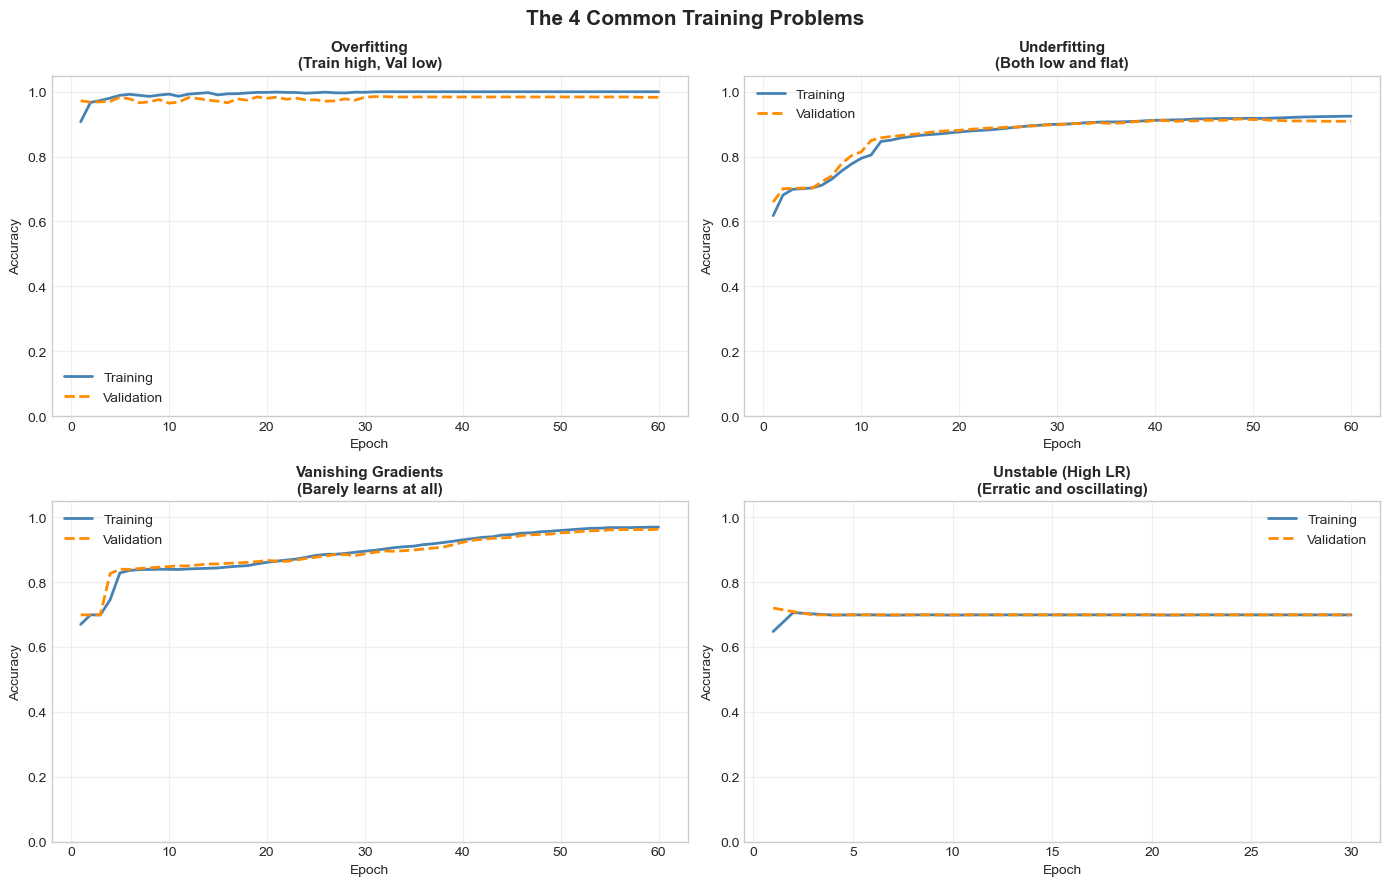

In [34]:
# Plot all 4 problems side by side so we can see the patterns clearly

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('The 4 Common Training Problems', fontsize=15, fontweight='bold')

histories = [
    (hist_overfit,   "Overfitting",         "Train high, Val low"),
    (hist_underfit,  "Underfitting",         "Both low and flat"),
    (hist_vanishing, "Vanishing Gradients",  "Barely learns at all"),
    (hist_exploding, "Unstable (High LR)",   "Erratic and oscillating"),
]

for ax, (hist, title, subtitle) in zip(axes.flat, histories):
    x = range(1, len(hist.history['accuracy']) + 1)
    ax.plot(x, hist.history['accuracy'],     color='steelblue',  lw=2, label='Training')
    ax.plot(x, hist.history['val_accuracy'], color='darkorange', lw=2, linestyle='--', label='Validation')
    ax.set_title(f"{title}\n({subtitle})", fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_problems.png', dpi=150, bbox_inches='tight')
plt.show()


##  Step 3: Fix All 4 Problems

| Problem | Fix |
|---|---|
| Overfitting | Dropout + L2 regularization + EarlyStopping |
| Underfitting | Bigger model, more layers, train longer |
| Vanishing Gradients | Replace sigmoid with ReLU + add BatchNormalization |
| Exploding Gradients | Gradient Clipping + lower learning rate |

We will now build one clean model that applies all of these fixes.

In [35]:
# The FIXED model — applying every solution at once

def build_good_model(dropout_rate=0.3, l2_lambda=0.001, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(20,)),

        # Block 1
        layers.Dense(128, kernel_regularizer=keras.regularizers.l2(l2_lambda)),
        layers.BatchNormalization(),  # Stabilizes training
        layers.Activation('relu'),    # Fixes vanishing gradients
        layers.Dropout(dropout_rate), # Prevents memorization

        # Block 2
        layers.Dense(64, kernel_regularizer=keras.regularizers.l2(l2_lambda)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),

        # Block 3
        layers.Dense(32, kernel_regularizer=keras.regularizers.l2(l2_lambda)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate / 2),

        # Output
        layers.Dense(1, activation='sigmoid')
    ])
    return model

print("Model function ready")

Model function ready


In [36]:
# Compile the good model
# clipnorm=1.0 handles exploding gradients inside the optimizer

good_model = build_good_model()
good_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

good_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                     │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 448 (1.75 KB)


##  Step 4: Learning Rate — The Most Important Hyperparameter

| Setting | What Happens |
|---|---|
| Too High (≥ 0.1) | Loss becomes NaN, training falls apart |
| Optimal (0.001 to 0.01) | Smooth convergence, reaches good performance |
| Too Low (≤ 0.0001) | Training crawls, gets stuck |

We will train the same model with 3 learning rates and compare.

In [38]:
# Train 3 identical models — only the learning rate changes

def train_with_lr(lr, epochs=35):
    m = keras.Sequential([
        layers.Input(shape=(20,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy', metrics=['accuracy']
    )
    return m.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=epochs, batch_size=64, verbose=0)

print("Training 3 models with different learning rates...")
hist_lr_high = train_with_lr(0.5)
hist_lr_good = train_with_lr(0.001)
hist_lr_low  = train_with_lr(0.00001)

Training 3 models with different learning rates...


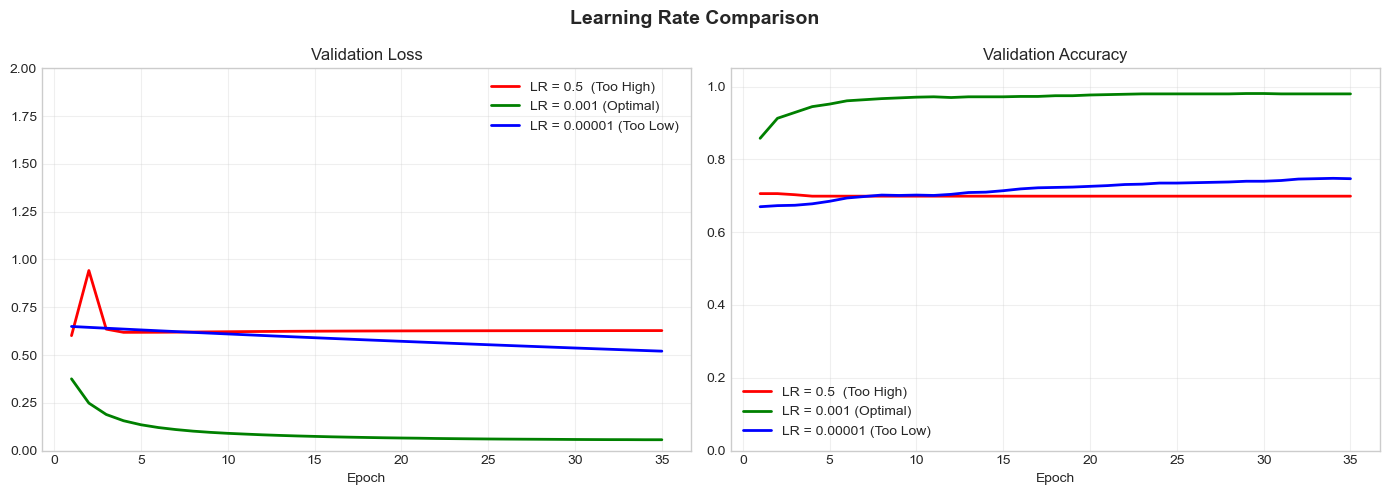

In [39]:
# Plot the learning rate comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Rate Comparison', fontsize=14, fontweight='bold')

lr_results = [
    (hist_lr_high, 'LR = 0.5  (Too High)',    'red'),
    (hist_lr_good, 'LR = 0.001 (Optimal)',    'green'),
    (hist_lr_low,  'LR = 0.00001 (Too Low)',  'blue'),
]

for hist, label, color in lr_results:
    x = range(1, len(hist.history['loss']) + 1)
    axes[0].plot(x, hist.history['val_loss'],     color=color, lw=2, label=label)
    axes[1].plot(x, hist.history['val_accuracy'], color=color, lw=2, label=label)

axes[0].set_title('Validation Loss');     axes[0].legend(); axes[0].set_ylim(0, 2)
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].set_ylim(0, 1.05)

for ax in axes:
    ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Summary of what we just saw

print("Final Validation Accuracy by Learning Rate:")
print(f"  LR = 0.5      (Too High):  {hist_lr_high.history['val_accuracy'][-1]*100:.1f}%  → unstable")
print(f"  LR = 0.001    (Optimal):   {hist_lr_good.history['val_accuracy'][-1]*100:.1f}%  → best ")
print(f"  LR = 0.00001  (Too Low):   {hist_lr_low.history['val_accuracy'][-1]*100:.1f}%  → barely moved")

Final Validation Accuracy by Learning Rate:
  LR = 0.5      (Too High):  69.9%  → unstable
  LR = 0.001    (Optimal):   98.0%  → best 
  LR = 0.00001  (Too Low):   74.7%  → barely moved


### The 3 Essential Callbacks

Think of callbacks as automatic assistants watching your training.

| Callback | What It Does | Why It Matters |
|---|---|---|
| ModelCheckpoint | Saves the best model automatically | You never lose progress |
| EarlyStopping | Stops when no improvement | Prevents overfitting, saves time |
| ReduceLROnPlateau | Lowers learning rate when stuck | Helps fine-tune near the end |

Always use all three together.

In [42]:
# Callback 1: ModelCheckpoint
# Saves the model only when validation accuracy improves

checkpoint_cb = ModelCheckpoint(
    filepath='best_model_day23.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
print("ModelCheckpoint ready")

ModelCheckpoint ready


In [43]:
# Callback 2: EarlyStopping
# Stops training if val_loss does not improve for 10 epochs
# restore_best_weights goes back to the best point before stopping

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
print("EarlyStopping ready")

EarlyStopping ready


In [44]:
# Callback 3: ReduceLROnPlateau
# If val_loss does not improve for 5 epochs — cut learning rate by half

reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)
print("ReduceLROnPlateau ready")

ReduceLROnPlateau ready


In [45]:
# Build the final model and train with all 3 callbacks active

final_model = build_good_model()
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training with all 3 callbacks...\n")

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,        # EarlyStopping will stop us before 100
    batch_size=64,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb],
    verbose=1
)

Training with all 3 callbacks...

Epoch 1/100
43/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5853 - loss: 0.8467
Epoch 1: val_accuracy improved from None to 0.88700, saving model to best_model_day23.keras

Epoch 1: finished saving model to best_model_day23.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.6873 - loss: 0.7373 - val_accuracy: 0.8870 - val_loss: 0.6075 - learning_rate: 0.0010
Epoch 2/100
45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8481 - loss: 0.5527
Epoch 2: val_accuracy improved from 0.88700 to 0.92000, saving model to best_model_day23.keras

Epoch 2: finished saving model to best_model_day23.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8617 - loss: 0.5195 - val_accuracy: 0.9200 - val_loss: 0.4921 - learning_rate: 0.0010
Epoch 3/100
41/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.4553
Epoch 3: val_accuracy improved from 0.92000 to 0.94100, saving model to best_model_day23.keras

Epoch 3: finished saving model 

In [46]:
print(" Training complete!")
print(f"   Stopped at epoch:  {len(history.history['accuracy'])}")
print(f"   Best val accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

 Training complete!
   Stopped at epoch:  85
   Best val accuracy: 98.90%


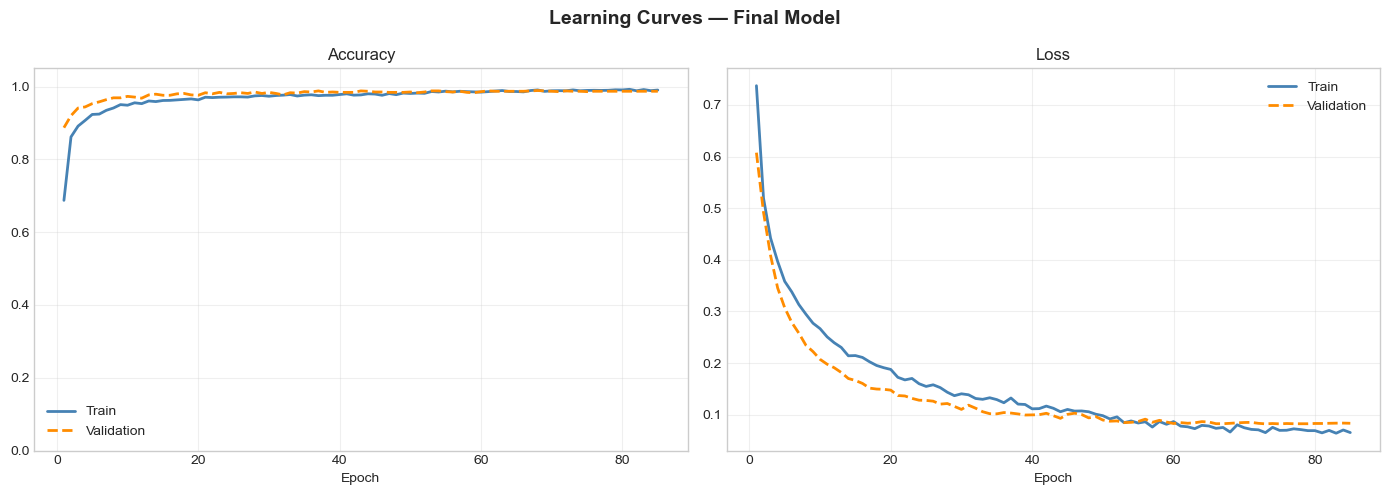

In [47]:
# Plot the learning curves
# These tell us whether we have a good fit, overfitting, or underfitting

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — Final Model', fontsize=14, fontweight='bold')

n = len(history.history['accuracy'])
x = range(1, n + 1)

axes[0].plot(x, history.history['accuracy'],     color='steelblue',  lw=2, label='Train')
axes[0].plot(x, history.history['val_accuracy'], color='darkorange', lw=2, linestyle='--', label='Validation')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].set_ylim(0, 1.05)

axes[1].plot(x, history.history['loss'],     color='steelblue',  lw=2, label='Train')
axes[1].plot(x, history.history['val_loss'], color='darkorange', lw=2, linestyle='--', label='Validation')
axes[1].set_title('Loss'); axes[1].legend()

for ax in axes:
    ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# Diagnose the learning curve automatically

train_acc = history.history['accuracy'][-1]
val_acc   = history.history['val_accuracy'][-1]
gap       = train_acc - val_acc

print(f"Train Accuracy:      {train_acc*100:.1f}%")
print(f"Validation Accuracy: {val_acc*100:.1f}%")
print(f"Gap:                 {gap*100:.1f}%")

if gap > 0.15:
    print("\n OVERFITTING — increase dropout or add more data")
elif train_acc < 0.75 and val_acc < 0.75:
    print("\n  UNDERFITTING — increase model size or train longer")
else:
    print("\n  GOOD FIT — training and validation are well aligned")

Train Accuracy:      99.0%
Validation Accuracy: 98.7%
Gap:                 0.3%

  GOOD FIT — training and validation are well aligned


##  Saving and Loading Models

In real work you always:
1. Save after training
2. Load separately when making predictions

We use a versioned filename so we always know which model is which.

In [50]:
import os
from datetime import datetime

# Create a versioned filename: version + accuracy + timestamp
best_val_acc = max(history.history['val_accuracy'])
acc_str      = f"{best_val_acc:.3f}".replace(".", "")
timestamp    = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name   = f"model_v1_acc{acc_str}_{timestamp}.keras"

final_model.save(model_name)
print(f" Saved as: {model_name}")

 Saved as: model_v1_acc0989_20260318_172902.keras


In [51]:
# Load the best checkpoint that ModelCheckpoint saved for us

best_model = keras.models.load_model('best_model_day23.keras')
print("Best model loaded successfully")

# Quick check — predictions from both models should match
p1 = final_model.predict(X_val[:3], verbose=0).flatten()
p2 = best_model.predict(X_val[:3],  verbose=0).flatten()

print(f"\nOriginal model predictions: {np.round(p1, 4)}")
print(f"Loaded model predictions:   {np.round(p2, 4)}")

Best model loaded successfully

Original model predictions: [0.0013 0.0003 0.0007]
Loaded model predictions:   [0.0013 0.0002 0.0005]
